# Visualização dos Resultados de Treinamento

Este notebook carrega e visualiza os dados de treinamento salvos em arquivos `.npy` na pasta `results/training`.

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

# Configurar estilo dos gráficos
plt.style.use('default')
sns.set_palette("husl")

## Configuração dos Diretórios

In [2]:
# Diretório com os resultados de treinamento
results_dir = Path("../results/training")

# Verificar se o diretório existe
if not results_dir.exists():
    print(f"ATENÇÃO: O diretório {results_dir} não foi encontrado!")
    print("Certifique-se de que o caminho está correto.")
else:
    print(f"Diretório encontrado: {results_dir}")
    print(f"\nArquivos disponíveis:")
    for file in sorted(results_dir.glob("*.npy")):
        print(f"  - {file.name}")

Diretório encontrado: ../results/training

Arquivos disponíveis:
  - B4S1000_est_params.npy
  - B4S1000_est_params_noise.npy
  - B4S1000_loss_history.npy
  - B4S1000_loss_history_noise.npy
  - B4S1000_param_history.npy
  - B4S1000_param_history_noise.npy


## Função Auxiliar para Carregar Dados

In [5]:
def carregar_arquivo_npy(nome_arquivo, descricao=""):
    """
    Carrega um arquivo .npy e exibe informações básicas.
    
    Args:
        nome_arquivo: Nome do arquivo (com ou sem extensão .npy)
        descricao: Descrição do conteúdo do arquivo
    
    Returns:
        Dados carregados do arquivo
    """
    # Garantir que o nome termine com .npy
    if not nome_arquivo.endswith('.npy'):
        nome_arquivo += '.npy'
    
    caminho = results_dir / nome_arquivo
    
    if not caminho.exists():
        print(f"ERRO: Arquivo {nome_arquivo} não encontrado!")
        return None
    
    try:
        # Tentar diferentes métodos de carregamento
        # Primeiro: tentar como array binário padrão
        dados = np.load(caminho, allow_pickle=False)
    except (ValueError, OSError):
        try:
            # Segundo: tentar com pickle habilitado
            dados = np.load(caminho, allow_pickle=True)
        except Exception:
            try:
                # Terceiro: tentar carregar como arquivo de texto
                dados = np.loadtxt(caminho)
            except Exception as e:
                print(f"ERRO ao carregar arquivo: {e}")
                return None
    
    print(f"\n{'='*60}")
    print(f"Arquivo: {nome_arquivo}")
    if descricao:
        print(f"Descrição: {descricao}")
    
    # Verificar se é um array ou objeto
    if isinstance(dados, np.ndarray):
        print(f"Shape: {dados.shape}")
        print(f"Dtype: {dados.dtype}")
        if dados.size > 0 and np.issubdtype(dados.dtype, np.number):
            print(f"Min: {np.min(dados):.6f}, Max: {np.max(dados):.6f}")
            print(f"Mean: {np.mean(dados):.6f}, Std: {np.std(dados):.6f}")
    else:
        print(f"Tipo: {type(dados)}")
        if hasattr(dados, 'shape'):
            print(f"Shape: {dados.shape}")
    
    print(f"{'='*60}")
    
    return dados

## Carregar Dados de Treinamento

Baseado na estrutura de arquivos observada, vamos carregar:
- Loss history (histórico de perda)
- Estimated parameters (parâmetros finais estimados)
- Parameter history (histórico de parâmetros ao longo do treinamento)

In [6]:
# Carregar histórico de loss
loss_history = carregar_arquivo_npy(
    "B4S1000_loss_history",
    "Histórico da função de perda durante o treinamento"
)


Arquivo: B4S1000_loss_history.npy
Descrição: Histórico da função de perda durante o treinamento
Shape: (1000,)
Dtype: float64
Min: 0.000027, Max: 0.031032
Mean: 0.000582, Std: 0.002353


In [7]:
# Carregar parâmetros estimados
est_params = carregar_arquivo_npy(
    "B4S1000_est_params",
    "Parâmetros finais estimados do modelo"
)


Arquivo: B4S1000_est_params.npy
Descrição: Parâmetros finais estimados do modelo
Shape: (375,)
Dtype: float64
Min: -3.241267, Max: 3.852731
Mean: 0.019924, Std: 0.946394


In [8]:
# Carregar histórico de parâmetros
param_history = carregar_arquivo_npy(
    "B4S1000_param_history",
    "Histórico dos parâmetros ao longo do treinamento"
)


Arquivo: B4S1000_param_history.npy
Descrição: Histórico dos parâmetros ao longo do treinamento
Shape: (1001, 375)
Dtype: float64
Min: -3.241267, Max: 3.852731
Mean: 0.019972, Std: 0.946332


## Comparação: Treinamento Normal vs Noisy

In [10]:
# Carregar versões noisy (se existirem)
loss_history_noise = carregar_arquivo_npy(
    "B4S1000_loss_history_noise",
    "Histórico da função de perda (com ruído)"
)

est_params_noise = carregar_arquivo_npy(
    "B4S1000_est_params_noise",
    "Parâmetros finais estimados (com ruído)"
)

param_history_noise = carregar_arquivo_npy(
    "B4S1000_param_history_noise",
    "Histórico dos parâmetros (com ruído)"
)


Arquivo: B4S1000_loss_history_noise.npy
Descrição: Histórico da função de perda (com ruído)
Shape: (500,)
Dtype: float64
Min: 0.000017, Max: 0.010403
Mean: 0.000327, Std: 0.001109

Arquivo: B4S1000_est_params_noise.npy
Descrição: Parâmetros finais estimados (com ruído)
Shape: (375,)
Dtype: float64
Min: -3.241267, Max: 3.852731
Mean: 0.019815, Std: 0.946640

Arquivo: B4S1000_param_history_noise.npy
Descrição: Histórico dos parâmetros (com ruído)
Shape: (501, 375)
Dtype: float64
Min: -3.241267, Max: 3.852731
Mean: 0.020103, Std: 0.946485


## Conversão de Dados (se necessário)

Alguns arquivos podem conter objetos que precisam ser convertidos para arrays NumPy.

In [11]:
def converter_para_array(dados):
    """Converte dados para array NumPy se necessário."""
    if dados is None:
        return None
    
    if isinstance(dados, np.ndarray):
        # Se já é um array, verificar se não é array de objetos
        if dados.dtype == object:
            # Tentar converter para float
            try:
                return np.array(dados, dtype=float)
            except:
                return dados
        return dados
    elif isinstance(dados, (list, tuple)):
        return np.array(dados)
    else:
        # Para outros tipos, tentar converter
        try:
            return np.array(dados)
        except:
            return dados

# Converter todos os dados carregados
loss_history = converter_para_array(loss_history)
est_params = converter_para_array(est_params)
param_history = converter_para_array(param_history)
loss_history_noise = converter_para_array(loss_history_noise)
est_params_noise = converter_para_array(est_params_noise)
param_history_noise = converter_para_array(param_history_noise)

print("\nDados convertidos com sucesso!")
print(f"Loss history shape: {loss_history.shape if loss_history is not None else 'N/A'}")
print(f"Est params shape: {est_params.shape if est_params is not None else 'N/A'}")
print(f"Param history shape: {param_history.shape if param_history is not None else 'N/A'}")


Dados convertidos com sucesso!
Loss history shape: (1000,)
Est params shape: (375,)
Param history shape: (1001, 375)


## Visualizações

### 1. Curva de Loss (Função de Perda)

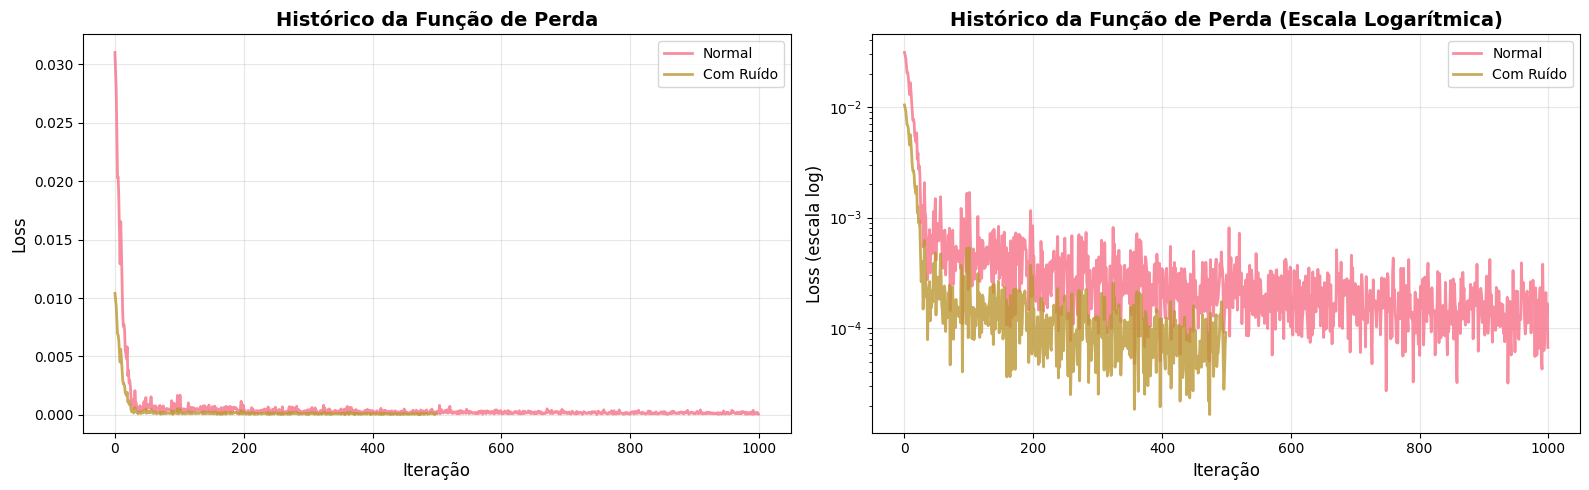


Loss final (Normal): 0.000067
Loss inicial (Normal): 0.031032
Redução: 99.78%

Loss final (Noisy): 0.000092
Loss inicial (Noisy): 0.010403
Redução: 99.12%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Comparação loss normal vs noisy
if loss_history is not None and loss_history.size > 0:
    axes[0].plot(loss_history, label='Normal', linewidth=2, alpha=0.8)
if loss_history_noise is not None and loss_history_noise.size > 0:
    axes[0].plot(loss_history_noise, label='Com Ruído', linewidth=2, alpha=0.8)

axes[0].set_xlabel('Iteração', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Histórico da Função de Perda', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Loss em escala logarítmica
if loss_history is not None and loss_history.size > 0:
    axes[1].semilogy(loss_history, label='Normal', linewidth=2, alpha=0.8)
if loss_history_noise is not None and loss_history_noise.size > 0:
    axes[1].semilogy(loss_history_noise, label='Com Ruído', linewidth=2, alpha=0.8)

axes[1].set_xlabel('Iteração', fontsize=12)
axes[1].set_ylabel('Loss (escala log)', fontsize=12)
axes[1].set_title('Histórico da Função de Perda (Escala Logarítmica)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas do loss final
if loss_history is not None and loss_history.size > 0:
    print(f"\nLoss final (Normal): {loss_history[-1]:.6f}")
    print(f"Loss inicial (Normal): {loss_history[0]:.6f}")
    print(f"Redução: {(1 - loss_history[-1]/loss_history[0])*100:.2f}%")

if loss_history_noise is not None and loss_history_noise.size > 0:
    print(f"\nLoss final (Noisy): {loss_history_noise[-1]:.6f}")
    print(f"Loss inicial (Noisy): {loss_history_noise[0]:.6f}")
    print(f"Redução: {(1 - loss_history_noise[-1]/loss_history_noise[0])*100:.2f}%")

### 2. Distribuição dos Parâmetros Finais

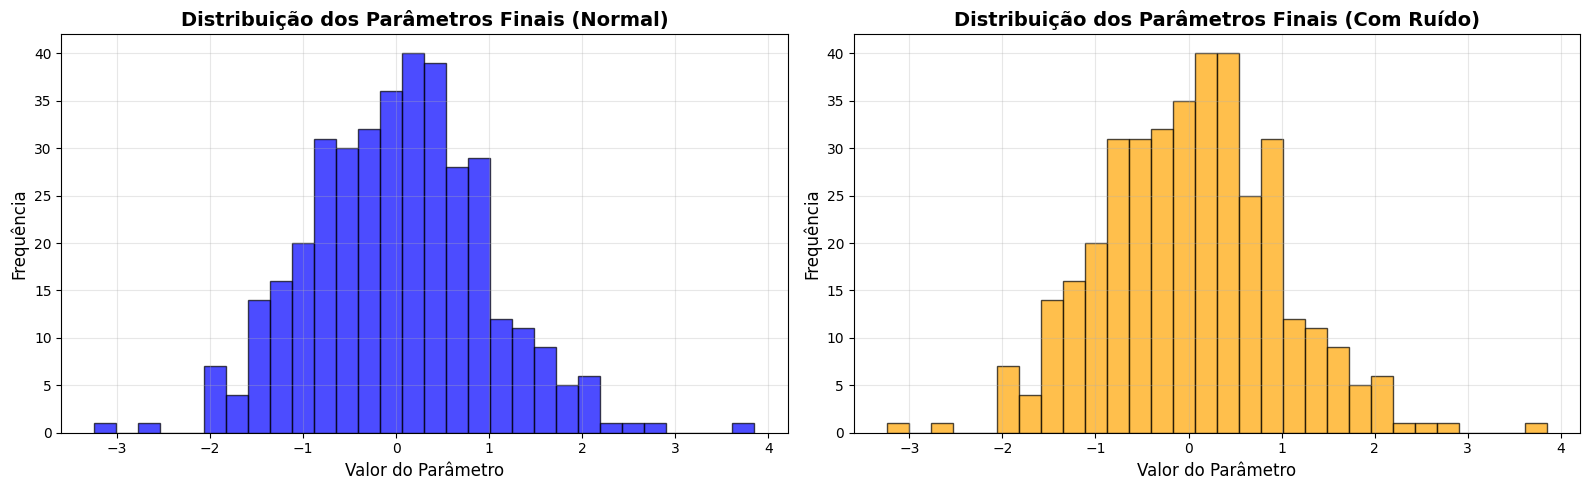

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma dos parâmetros normais
if est_params is not None and est_params.size > 0:
    axes[0].hist(est_params.flatten(), bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_xlabel('Valor do Parâmetro', fontsize=12)
    axes[0].set_ylabel('Frequência', fontsize=12)
    axes[0].set_title('Distribuição dos Parâmetros Finais (Normal)', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'Dados não disponíveis', 
                ha='center', va='center', fontsize=14, transform=axes[0].transAxes)
    axes[0].axis('off')

# Histograma dos parâmetros com ruído
if est_params_noise is not None and est_params_noise.size > 0:
    axes[1].hist(est_params_noise.flatten(), bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[1].set_xlabel('Valor do Parâmetro', fontsize=12)
    axes[1].set_ylabel('Frequência', fontsize=12)
    axes[1].set_title('Distribuição dos Parâmetros Finais (Com Ruído)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Dados não disponíveis', 
                ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

### 3. Evolução dos Parâmetros ao Longo do Treinamento

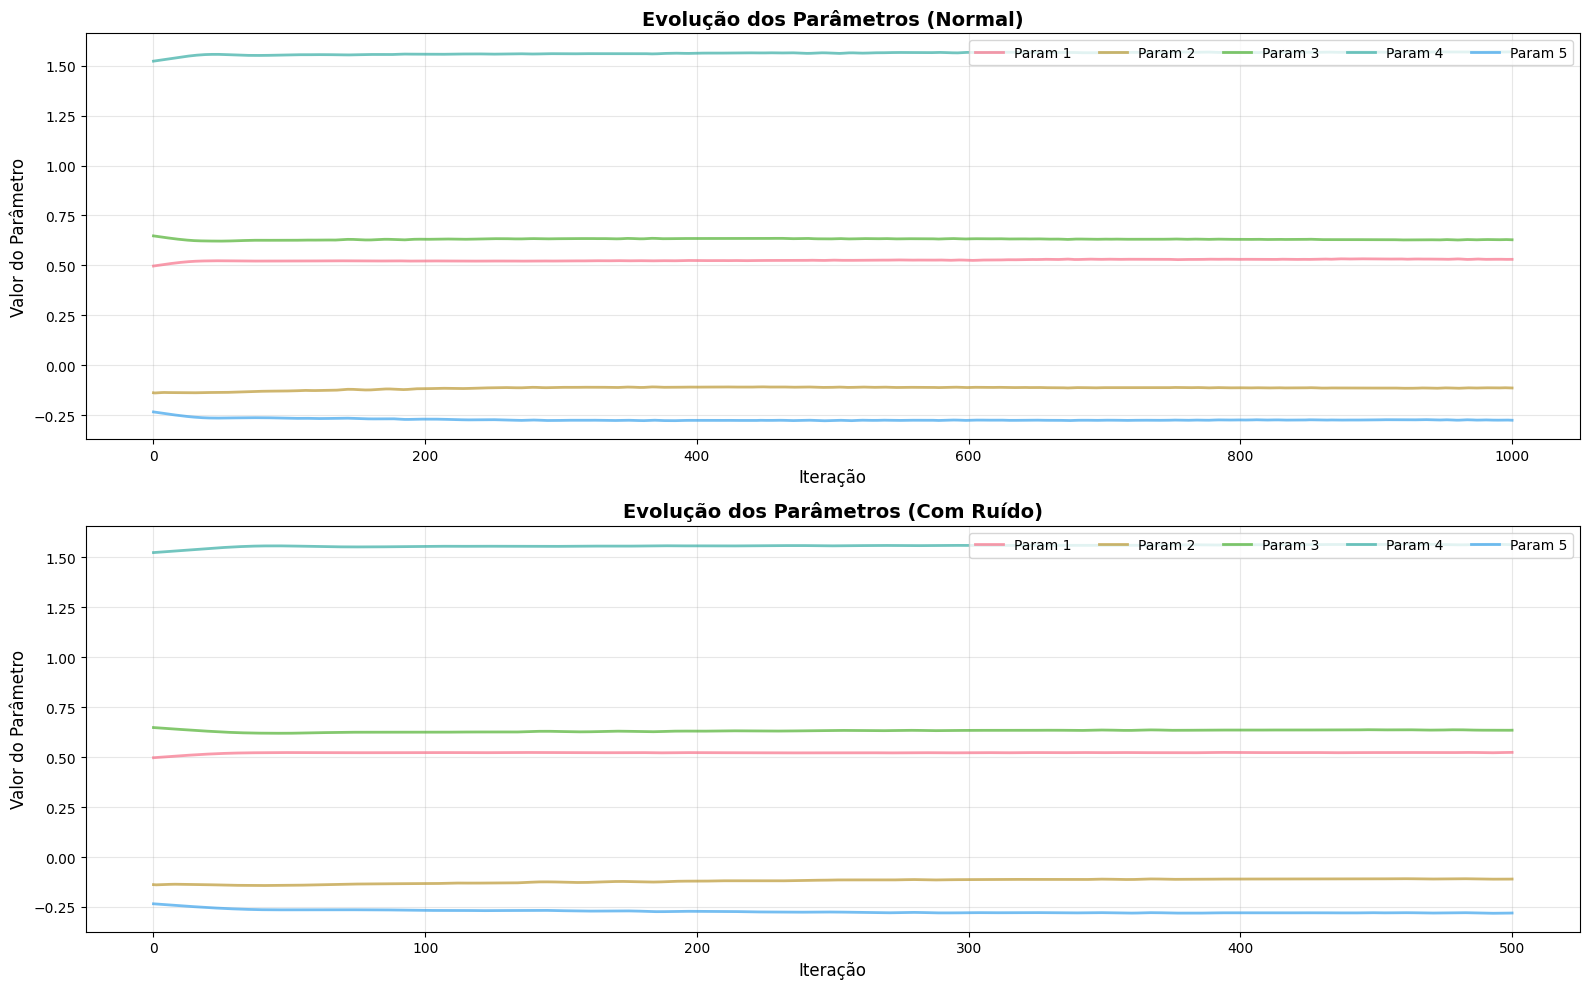

In [14]:
# Visualizar a evolução de alguns parâmetros específicos
if param_history is not None and param_history.size > 0:
    # Selecionar alguns parâmetros para visualizar (primeiros 5, por exemplo)
    if len(param_history.shape) == 2:
        num_params_to_plot = min(5, param_history.shape[1])
    else:
        num_params_to_plot = 1
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # Plot 1: Normal
    if len(param_history.shape) == 2:
        for i in range(num_params_to_plot):
            axes[0].plot(param_history[:, i], label=f'Param {i+1}', alpha=0.7, linewidth=2)
    else:
        axes[0].plot(param_history, label='Parâmetros', alpha=0.7, linewidth=2)
    
    axes[0].set_xlabel('Iteração', fontsize=12)
    axes[0].set_ylabel('Valor do Parâmetro', fontsize=12)
    axes[0].set_title('Evolução dos Parâmetros (Normal)', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10, ncol=num_params_to_plot if len(param_history.shape) == 2 else 1)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Com ruído (se disponível)
    if param_history_noise is not None and param_history_noise.size > 0:
        if len(param_history_noise.shape) == 2:
            for i in range(num_params_to_plot):
                axes[1].plot(param_history_noise[:, i], label=f'Param {i+1}', alpha=0.7, linewidth=2)
        else:
            axes[1].plot(param_history_noise, label='Parâmetros', alpha=0.7, linewidth=2)
        
        axes[1].set_xlabel('Iteração', fontsize=12)
        axes[1].set_ylabel('Valor do Parâmetro', fontsize=12)
        axes[1].set_title('Evolução dos Parâmetros (Com Ruído)', fontsize=14, fontweight='bold')
        axes[1].legend(fontsize=10, ncol=num_params_to_plot if len(param_history_noise.shape) == 2 else 1)
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'Dados de parâmetros com ruído não disponíveis', 
                    ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
        axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Dados de histórico de parâmetros não disponíveis.")

### 4. Heatmap da Evolução dos Parâmetros

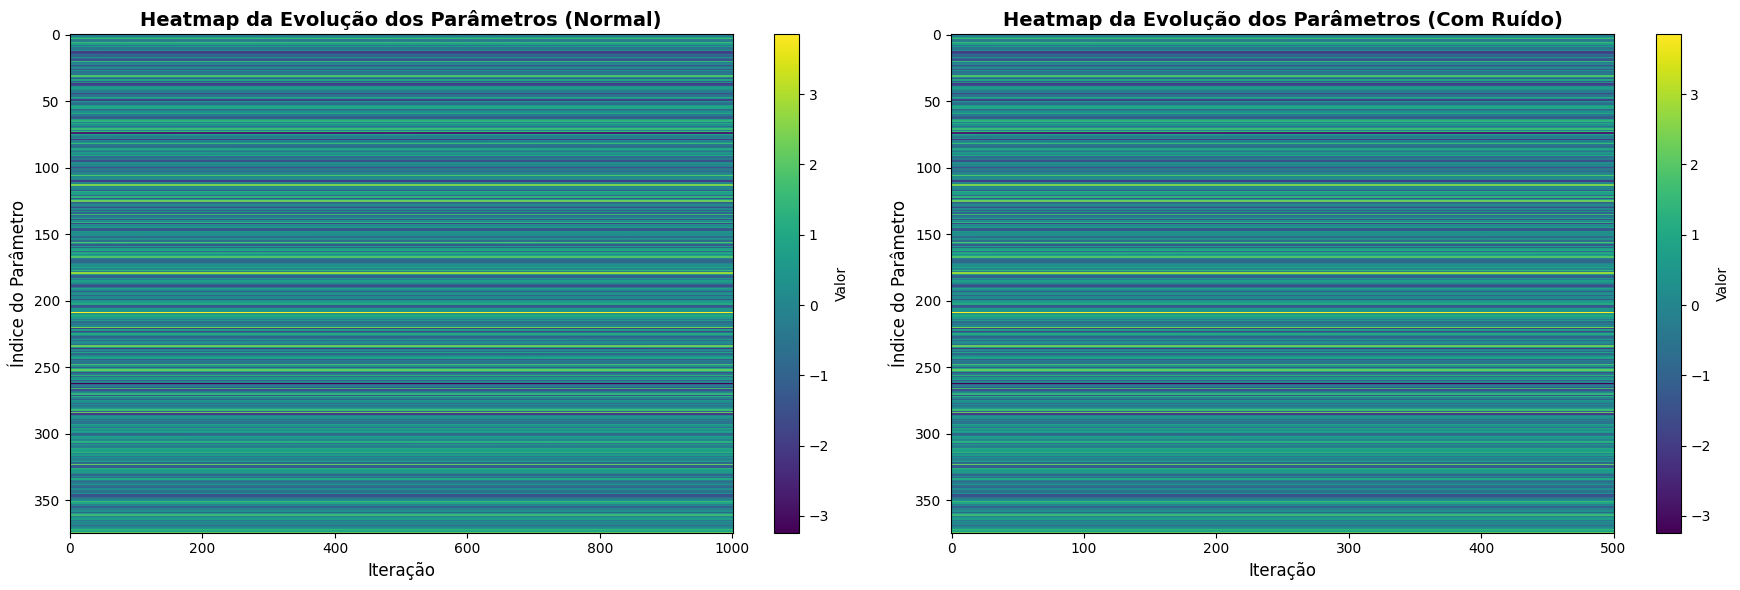

In [15]:
if param_history is not None and param_history.size > 0 and len(param_history.shape) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Normal
    im1 = axes[0].imshow(param_history.T, aspect='auto', cmap='viridis', interpolation='nearest')
    axes[0].set_xlabel('Iteração', fontsize=12)
    axes[0].set_ylabel('Índice do Parâmetro', fontsize=12)
    axes[0].set_title('Heatmap da Evolução dos Parâmetros (Normal)', fontsize=14, fontweight='bold')
    plt.colorbar(im1, ax=axes[0], label='Valor')
    
    # Com ruído
    if param_history_noise is not None and param_history_noise.size > 0 and len(param_history_noise.shape) == 2:
        im2 = axes[1].imshow(param_history_noise.T, aspect='auto', cmap='viridis', interpolation='nearest')
        axes[1].set_xlabel('Iteração', fontsize=12)
        axes[1].set_ylabel('Índice do Parâmetro', fontsize=12)
        axes[1].set_title('Heatmap da Evolução dos Parâmetros (Com Ruído)', fontsize=14, fontweight='bold')
        plt.colorbar(im2, ax=axes[1], label='Valor')
    else:
        axes[1].text(0.5, 0.5, 'Dados de parâmetros com ruído não disponíveis', 
                    ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
        axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Heatmap não disponível - dados não têm estrutura 2D adequada.")

### 5. Análise de Convergência

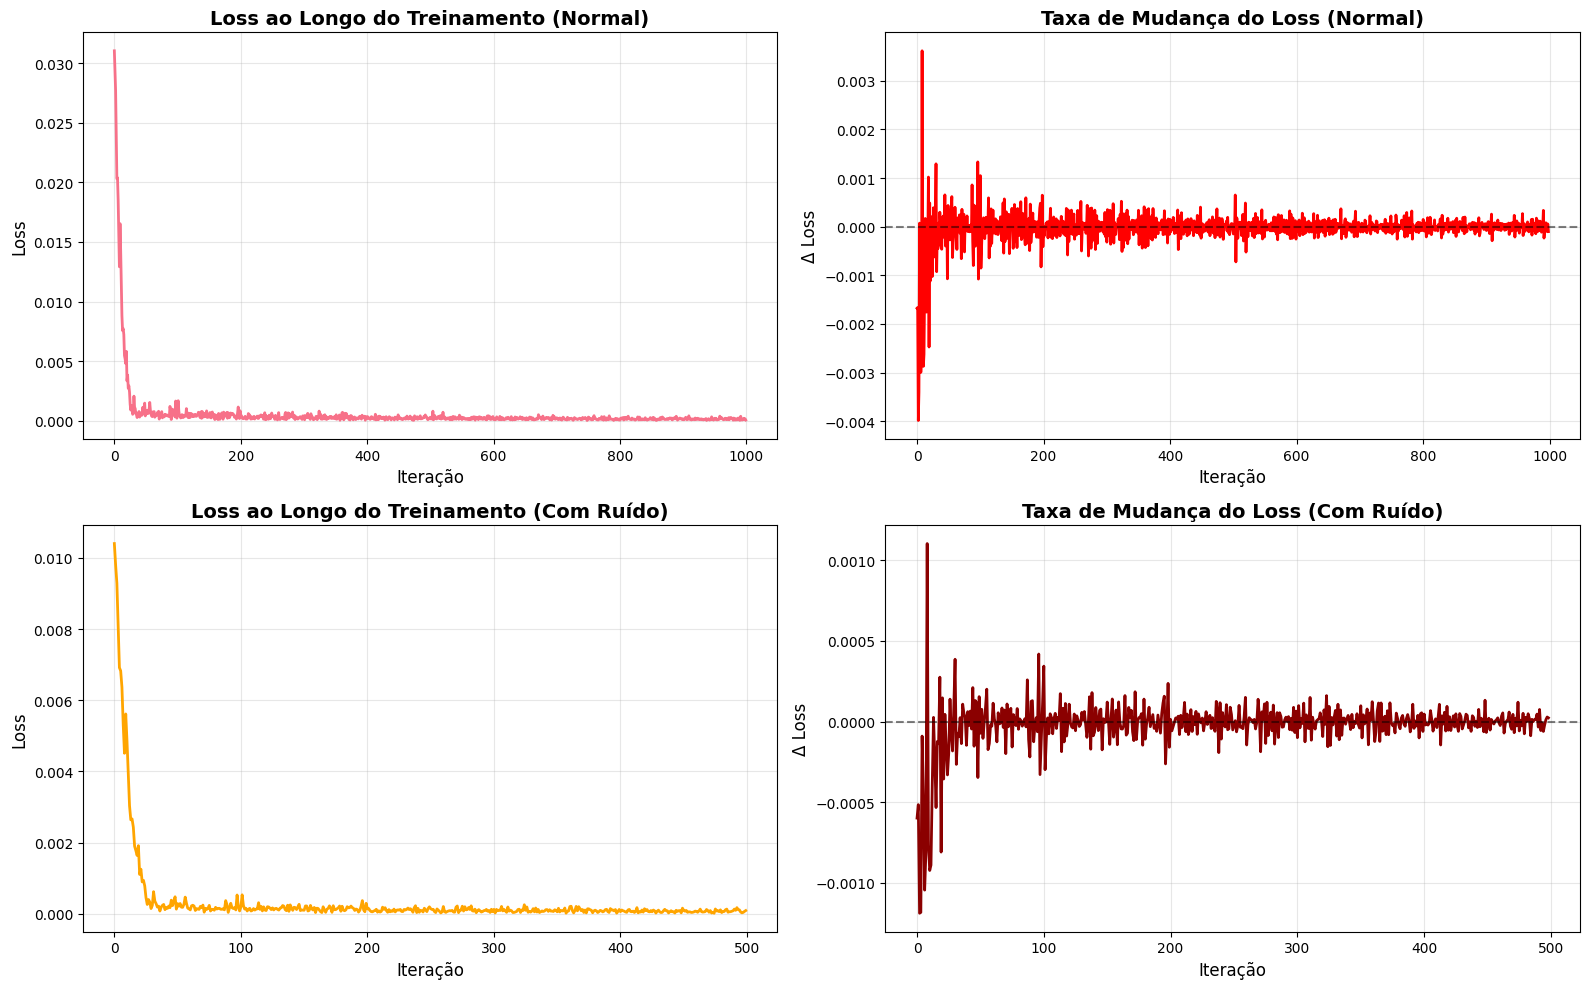

In [16]:
if loss_history is not None and loss_history.size > 1:
    # Calcular a variação do loss (primeira derivada aproximada)
    loss_diff = np.diff(loss_history)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Loss normal
    axes[0, 0].plot(loss_history, linewidth=2)
    axes[0, 0].set_xlabel('Iteração', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Loss ao Longo do Treinamento (Normal)', fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Taxa de mudança do loss
    axes[0, 1].plot(loss_diff, linewidth=2, color='red')
    axes[0, 1].set_xlabel('Iteração', fontsize=12)
    axes[0, 1].set_ylabel('Δ Loss', fontsize=12)
    axes[0, 1].set_title('Taxa de Mudança do Loss (Normal)', fontsize=14, fontweight='bold')
    axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Com ruído (se disponível)
    if loss_history_noise is not None and loss_history_noise.size > 1:
        loss_diff_noise = np.diff(loss_history_noise)
        
        axes[1, 0].plot(loss_history_noise, linewidth=2, color='orange')
        axes[1, 0].set_xlabel('Iteração', fontsize=12)
        axes[1, 0].set_ylabel('Loss', fontsize=12)
        axes[1, 0].set_title('Loss ao Longo do Treinamento (Com Ruído)', fontsize=14, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].plot(loss_diff_noise, linewidth=2, color='darkred')
        axes[1, 1].set_xlabel('Iteração', fontsize=12)
        axes[1, 1].set_ylabel('Δ Loss', fontsize=12)
        axes[1, 1].set_title('Taxa de Mudança do Loss (Com Ruído)', fontsize=14, fontweight='bold')
        axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[1, 1].grid(True, alpha=0.3)
    else:
        for ax in [axes[1, 0], axes[1, 1]]:
            ax.text(0.5, 0.5, 'Dados com ruído não disponíveis', 
                   ha='center', va='center', fontsize=14, transform=ax.transAxes)
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Análise de convergência não disponível - dados insuficientes.")

### 6. Resumo Estatístico

In [17]:
# Criar tabela comparativa
summary_data = []

if loss_history is not None and loss_history.size > 0:
    summary_data.append({
        'Versão': 'Normal',
        'Loss Inicial': f"{loss_history[0]:.6f}",
        'Loss Final': f"{loss_history[-1]:.6f}",
        'Redução (%)': f"{(1 - loss_history[-1]/loss_history[0])*100:.2f}%",
        'Nº Iterações': len(loss_history),
        'Nº Parâmetros': est_params.size if est_params is not None else 'N/A'
    })

if loss_history_noise is not None and loss_history_noise.size > 0:
    summary_data.append({
        'Versão': 'Com Ruído',
        'Loss Inicial': f"{loss_history_noise[0]:.6f}",
        'Loss Final': f"{loss_history_noise[-1]:.6f}",
        'Redução (%)': f"{(1 - loss_history_noise[-1]/loss_history_noise[0])*100:.2f}%",
        'Nº Iterações': len(loss_history_noise),
        'Nº Parâmetros': est_params_noise.size if est_params_noise is not None else 'N/A'
    })

if summary_data:
    df_summary = pd.DataFrame(summary_data)
    print("\n" + "="*80)
    print("RESUMO COMPARATIVO DO TREINAMENTO")
    print("="*80)
    print(df_summary.to_string(index=False))
    print("="*80)
else:
    print("Não há dados suficientes para criar o resumo.")


RESUMO COMPARATIVO DO TREINAMENTO
   Versão Loss Inicial Loss Final Redução (%)  Nº Iterações  Nº Parâmetros
   Normal     0.031032   0.000067      99.78%          1000            375
Com Ruído     0.010403   0.000092      99.12%           500            375


## Exportar Gráficos

Salvar os principais gráficos como imagens.

In [18]:
# Criar diretório para salvar gráficos
output_dir = Path("../results/visualizations")
output_dir.mkdir(parents=True, exist_ok=True)

# Gráfico de loss comparativo
if (loss_history is not None and loss_history.size > 0) or (loss_history_noise is not None and loss_history_noise.size > 0):
    plt.figure(figsize=(12, 6))
    
    if loss_history is not None and loss_history.size > 0:
        plt.plot(loss_history, label='Normal', linewidth=2, alpha=0.8)
    if loss_history_noise is not None and loss_history_noise.size > 0:
        plt.plot(loss_history_noise, label='Com Ruído', linewidth=2, alpha=0.8)
    
    plt.xlabel('Iteração', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Comparação: Histórico da Função de Perda', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    save_path = output_dir / 'loss_comparison.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Gráfico salvo em: {save_path}")
    plt.close()

print("\nVisualização concluída!")

Gráfico salvo em: ../results/visualizations/loss_comparison.png

Visualização concluída!
